# Football Match Outcome Prediction

Author: Aleksandr Rizov  
Course: Data Science  12.05.2026 

## 1. Introduction

Predicting football match outcomes is a challenging problem in sports analytics. 
It has applications in betting, performance analysis, and decision-making.

The goal of this project is to build a machine learning model that predicts match outcomes 
(home win, draw, or away win) using historical match data.

## 2. Problem Definition

This task is formulated as a multi-class classification problem.

Target classes:
- H: Home win  
- D: Draw  
- A: Away win  

The objective is to learn a function:

f(X) → y

## 3. Data Sources

In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
!pip install seaborn



[notice] A new release of pip is available: 25.1.1 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [39]:
data = pd.read_csv("Untitled Folder/example.csv")
data = pd.read_csv("Untitled Folder/SC1.csv")
data.head()


,Div,Date,Time,HomeTeam,AwayTeam,FTHG,FTAG,FTR,HTHG,HTAG,HTR,Referee,HS,AS,HST,AST,HF,AF,HC,AC,HY,AY,HR,AR,B365H,B365D,B365A,BFDH,BFDD,BFDA,BMGMH,BMGMD,BMGMA,BVH,BVD,BVA,BWH,BWD,BWA,CLH,CLD,CLA,LBH,LBD,LBA,PSH,PSD,PSA,MaxH,MaxD,MaxA,AvgH,AvgD,AvgA,BFEH,BFED,BFEA,B365>2.5,B365<2.5,P>2.5,P<2.5,Max>2.5,Max<2.5,Avg>2.5,Avg<2.5,BFE>2.5,BFE<2.5,AHh,B365AHH,B365AHA,PAHH,PAHA,MaxAHH,MaxAHA,AvgAHH,AvgAHA,BFEAHH,BFEAHA,B365CH,B365CD,B365CA,BFDCH,BFDCD,BFDCA,BMGMCH,BMGMCD,BMGMCA,BVCH,BVCD,BVCA,BWCH,BWCD,BWCA,CLCH,CLCD,CLCA,LBCH,LBCD,LBCA,PSCH,PSCD,PSCA,MaxCH,MaxCD,MaxCA,AvgCH,AvgCD,AvgCA,BFECH,BFECD,BFECA,B365C>2.5,B365C<2.5,PC>2.5,PC<2.5,MaxC>2.5,MaxC<2.5,AvgC>2.5,AvgC<2.5,BFEC>2.5,BFEC<2.5,AHCh,B365CAHH,B365CAHA,PCAHH,PCAHA,MaxCAHH,MaxCAHA,AvgCAHH,AvgCAHA,BFECAHH,BFECAHA
0,SC1,01/08/2025,19:45,Arbroath,Ayr,1,1,D,0,1,A,C Graham,11,3,4,1,10,15,6,2,2,5,0,0,3.90,3.80,1.75,4.33,3.60,1.73,3.70,3.65,1.82,4.33,3.60,1.7,3.90,3.60,1.71,3.90,3.60,1.73,3.90,3.60,1.73,4.01,4.15,1.78,4.40,4.15,1.82,3.96,3.68,1.75,4.40,4.20,1.79,1.83,1.98,1.85,1.98,1.85,1.98,1.81,1.89,1.86,2.12,0.50,2.05,1.75,2.09,1.75,2.09,1.84,1.98,1.76,2.20,1.78,3.9,3.9,1.75,4.33,3.60,1.73,4.30,3.80,1.68,4.33,3.6,1.70,3.90,3.60,1.71,3.90,3.6,1.73,3.90,3.6,1.73,4.23,3.92,1.78,4.40,3.90,1.77,4.17,3.67,1.71,4.90,4.10,1.77,1.84,1.84,1.85,1.98,1.87,1.93,1.82,1.88,1.85,2.10,0.75,1.83,1.98,1.84,2.02,1.83,2.00,1.77,1.91,1.95,1.98
1,SC1,02/08/2025,15:00,Airdrie Utd,Ross County,2,2,D,0,1,A,L Wilson,7,11,3,4,14,11,4,10,3,2,0,0,3.20,3.60,2.00,3.40,3.40,2.05,3.25,3.50,2.02,3.30,3.40,2.0,3.20,3.30,1.98,3.20,3.30,2.00,3.20,3.30,2.00,3.31,3.56,2.07,3.40,3.60,2.07,3.26,3.42,2.01,3.40,3.50,2.14,1.84,1.84,1.89,1.91,1.89,1.91,1.84,1.85,1.89,1.93,0.50,1.78,2.03,1.73,2.05,1.80,2.05,1.74,2.00,1.78,2.14,3.2,3.6,2.00,3.40,3.40,2.05,3.25,3.50,2.02,3.40,3.4,1.95,3.20,3.30,1.98,3.20,3.3,2.00,3.20,3.3,2.00,3.36,3.63,2.09,3.50,3.60,2.05,3.28,3.42,2.00,3.75,3.75,2.08,1.90,1.90,1.90,1.93,1.90,1.90,1.85,1.84,1.96,1.99,0.50,1.80,2.00,1.77,2.09,1.80,2.02,1.75,1.98,1.90,2.08
2,SC1,02/08/2025,15:00,Morton,Dunfermline,0,0,D,0,0,D,D McFarlane,7,12,1,9,19,10,1,8,3,1,0,0,2.75,2.88,2.60,2.80,2.88,2.63,2.80,2.90,2.55,2.75,2.88,2.6,2.65,2.85,2.50,2.70,2.87,2.50,2.70,2.87,2.50,2.86,2.86,2.73,2.86,2.90,2.73,2.77,2.87,2.58,2.88,2.98,2.86,2.63,1.44,2.66,1.46,2.66,1.48,2.60,1.44,2.64,1.50,0.00,1.98,1.83,1.95,1.86,1.98,1.86,1.93,1.81,1.95,1.99,2.6,2.9,2.70,2.63,2.88,2.88,2.80,2.90,2.55,2.63,2.9,2.70,2.50,2.87,2.60,2.50,2.9,2.62,2.50,2.9,2.62,2.78,2.91,2.89,2.80,3.00,2.88,2.63,2.89,2.68,2.66,3.05,3.05,2.50,1.50,2.68,1.48,2.65,1.50,2.54,1.46,2.60,1.56,0.00,1.85,1.95,1.88,1.97,1.85,1.95,1.82,1.91,1.82,2.07
3,SC1,02/08/2025,15:00,Raith Rvs,Queens Park,1,1,D,0,1,A,D Nicolson,12,3,2,3,11,7,10,2,1,3,0,0,1.36,4.50,7.50,1.36,4.50,8.50,1.33,4.75,8.00,1.33,4.50,8.0,1.34,4.40,7.00,1.35,4.40,7.00,1.35,4.40,7.00,1.36,4.67,7.90,1.37,4.75,8.50,1.34,4.53,7.76,1.40,4.70,7.80,1.74,1.94,1.82,1.99,1.82,1.99,1.77,1.93,1.83,1.99,-1.25,1.85,1.95,1.86,1.96,1.86,1.96,1.76,1.93,1.88,2.03,1.4,4.5,6.50,1.36,4.33,8.00,1.33,4.75,8.00,1.36,4.4,7.50,1.35,4.40,6.75,1.36,4.4,6.50,1.36,4.4,6.50,1.40,4.69,7.82,1.40,4.75,8.00,1.36,4.48,7.32,1.43,4.80,9.00,1.80,2.00,1.84,2.00,1.80,2.00,1.76,1.95,1.84,2.14,-1.25,1.93,1.88,1.93,1.93,1.93,1.94,1.78,1.89,1.97,1.92
4,SC1,02/08/2025,15:00,St Johnstone,Partick,5,1,H,3,1,H,R Hardie,20,3,11,1,15,14,7,1,2,2,0,0,1.85,3.60,3.50,1.90,3.40,4.00,1.96,3.30,3.65,1.87,3.30,3.9,1.85,3.30,3.60,1.85,3.30,3.60,1.85,3.30,3.60,1.91,3.59,3.76,1.96,3.60,4.00,1.89,3.38,3.70,1.94,3.55,4.10,2.05,1.72,2.04,1.73,2.05,1.73,2.01,1.72,2.06,1.77,-0.50,1.90,1.90,1.93,1.89,1.97,1.90,1.89,1.83,1.94,1.93,1.9,3.6,3.40,1.91,3.30,4.00,1.96,3.30,3.65,1.91,3.3,3.70,1.90,3.20,3.50,1.91,3.2,3.50,1.91,3.2,3.50,1.95,3.58,3.86,1.96,3.60,4.00,1.92,3.30,3.64,2.08,3.50,4.00,2.05,1.75,2.07,1.77,2.05,1.75,2.01,1.72,2.08,1.83,-0.50,1.95,1.85,1.95,1.89,1.97,1.85,1.92,1.80,2.08,1.87


In [9]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 175 entries, 0 to 174
Columns: 132 entries, Div to BFECAHA
dtypes: float64(108), int64(16), str(8)
memory usage: 180.6 KB


In [40]:
data.describe(include=np.float64)

,B365H,B365D,B365A,BFDH,BFDD,BFDA,BMGMH,BMGMD,BMGMA,BVH,BVD,BVA,BWH,BWD,BWA,CLH,CLD,CLA,LBH,LBD,LBA,PSH,PSD,PSA,MaxH,MaxD,MaxA,AvgH,AvgD,AvgA,BFEH,BFED,BFEA,B365>2.5,B365<2.5,P>2.5,P<2.5,Max>2.5,Max<2.5,Avg>2.5,Avg<2.5,BFE>2.5,BFE<2.5,AHh,B365AHH,B365AHA,PAHH,PAHA,MaxAHH,MaxAHA,AvgAHH,AvgAHA,BFEAHH,BFEAHA,B365CH,B365CD,B365CA,BFDCH,BFDCD,BFDCA,BMGMCH,BMGMCD,BMGMCA,BVCH,BVCD,BVCA,BWCH,BWCD,BWCA,CLCH,CLCD,CLCA,LBCH,LBCD,LBCA,PSCH,PSCD,PSCA,MaxCH,MaxCD,MaxCA,AvgCH,AvgCD,AvgCA,BFECH,BFECD,BFECA,B365C>2.5,B365C<2.5,PC>2.5,PC<2.5,MaxC>2.5,MaxC<2.5,AvgC>2.5,AvgC<2.5,BFEC>2.5,BFEC<2.5,AHCh,B365CAHH,B365CAHA,PCAHH,PCAHA,MaxCAHH,MaxCAHA,AvgCAHH,AvgCAHA,BFECAHH,BFECAHA
count,175.000000,175.000000,175.000000,175.000000,175.000000,175.000000,173.000000,173.000000,173.000000,175.000000,175.000000,175.000000,175.000000,175.000000,175.000000,127.000000,127.000000,127.000000,127.000000,127.000000,127.000000,59.000000,59.000000,59.000000,175.000000,175.000000,175.000000,175.000000,175.000000,175.000000,169.000000,169.000000,169.000000,175.000000,175.000000,59.000000,59.000000,175.000000,175.000000,175.000000,175.000000,164.000000,164.000000,175.000000,175.000000,175.000000,59.000000,59.000000,175.000000,175.000000,175.000000,175.000000,162.000000,162.000000,175.000000,175.000000,175.000000,171.000000,171.000000,171.000000,175.000000,175.000000,175.000000,171.000000,171.000000,171.000000,175.000000,175.000000,175.000000,115.000000,115.000000,115.000000,119.000000,119.000000,119.000000,60.000000,60.000000,60.000000,175.000000,175.000000,175.000000,175.000000,175.000000,175.000000,169.000000,169.000000,169.000000,175.000000,175.000000,60.000000,60.000000,175.00000,175.000000,175.00000,175.000000,169.000000,169.000000,175.000000,175.000000,175.000000,60.000000,60.000000,175.000000,175.000000,175.000000,175.000000,169.000000,169.000000
mean,2.470743,3.400343,3.404000,2.519886,3.365943,3.500229,2.523815,3.476301,3.411329,2.515029,3.425771,3.481943,2.422400,3.368571,3.256800,2.415748,3.384409,3.300787,2.415748,3.384409,3.300787,2.625763,3.576441,3.356102,2.633600,3.594514,3.663943,2.494229,3.411943,3.407143,2.528757,3.366686,3.526331,2.025657,1.795543,2.015932,1.818475,2.052171,1.820400,1.982629,1.762743,1.959939,1.770671,-0.204286,1.891600,1.913429,1.906780,1.916949,1.914057,1.928800,1.850857,1.862686,1.879198,1.912469,2.508171,3.395257,3.414571,2.541462,3.377018,3.543684,2.531829,3.460000,3.395886,2.557018,3.427544,3.542865,2.453029,3.364971,3.282800,2.484348,3.400870,3.290870,2.495462,3.394958,3.265714,2.663000,3.605500,3.443333,2.681829,3.599200,3.729200,2.529486,3.414571,3.448571,2.790296,3.703018,3.989822,2.048286,1.779371,2.033500,1.833833,2.06800,1.813429,1.99520,1.755543,2.112899,1.870296,-0.197143,1.894629,1.911086,1.892833,1.963000,1.925657,1.941943,1.851771,1.863257,1.958698,1.976982
std,0.955365,0.419618,1.607082,1.024834,0.420237,1.735072,1.011933,0.429966,1.575954,1.017287,0.434054,1.742237,0.899908,0.414238,1.456058,0.897539,0.381023,1.447467,0.897539,0.381023,1.447467,1.086658,0.420954,1.412877,1.114824,0.492291,1.863863,0.983214,0.417985,1.594636,1.100861,0.639461,1.854685,0.185644,0.160612,0.217249,0.167000,0.194215,0.163262,0.183290,0.147891,0.307127,0.191296,0.574278,0.093543,0.093923,0.102746,0.099052,0.098232,0.092812,0.088997,0.087849,0.186004,0.151756,1.005572,0.458891,1.677532,1.063740,0.458955,1.859941,1.048941,0.518896,1.621899,1.103232,0.471129,1.964940,0.956923,0.456254,1.555131,0.985603,0.460738,1.589496,0.987927,0.455819,1.568924,1.088282,0.443864,1.525544,1.158214,0.536542,2.026517,1.036601,0.458351,1.724199,1.314151,0.649260,2.353847,0.196640,0.167305,0.227699,0.176684,0.20509,0.166643,0.19135,0.154859,0.222896,0.183421,0.594267,0.093703,0.098748,0.104413,0.111162,0.104670,0.119586,0.080371,0.080052,0.120597,0.130807
min,1.220000,2.750000,1.450000,1.200000,2.750000,1.440000,1.240000,2.850000,1.410000,1.200000,2.880000,1.450000,1.230000,2.800000,1.460000,1.220000,2.800000,1.480000,1.220000,2.800000,1.480000,1.360000,2.

In [41]:
data.columns.tolist()

['Div',
 'Date',
 'Time',
 'HomeTeam',
 'AwayTeam',
 'FTHG',
 'FTAG',
 'FTR',
 'HTHG',
 'HTAG',
 'HTR',
 'Referee',
 'HS',
 'AS',
 'HST',
 'AST',
 'HF',
 'AF',
 'HC',
 'AC',
 'HY',
 'AY',
 'HR',
 'AR',
 'B365H',
 'B365D',
 'B365A',
 'BFDH',
 'BFDD',
 'BFDA',
 'BMGMH',
 'BMGMD',
 'BMGMA',
 'BVH',
 'BVD',
 'BVA',
 'BWH',
 'BWD',
 'BWA',
 'CLH',
 'CLD',
 'CLA',
 'LBH',
 'LBD',
 'LBA',
 'PSH',
 'PSD',
 'PSA',
 'MaxH',
 'MaxD',
 'MaxA',
 'AvgH',
 'AvgD',
 'AvgA',
 'BFEH',
 'BFED',
 'BFEA',
 'B365>2.5',
 'B365<2.5',
 'P>2.5',
 'P<2.5',
 'Max>2.5',
 'Max<2.5',
 'Avg>2.5',
 'Avg<2.5',
 'BFE>2.5',
 'BFE<2.5',
 'AHh',
 'B365AHH',
 'B365AHA',
 'PAHH',
 'PAHA',
 'MaxAHH',
 'MaxAHA',
 'AvgAHH',
 'AvgAHA',
 'BFEAHH',
 'BFEAHA',
 'B365CH',
 'B365CD',
 'B365CA',
 'BFDCH',
 'BFDCD',
 'BFDCA',
 'BMGMCH',
 'BMGMCD',
 'BMGMCA',
 'BVCH',
 'BVCD',
 'BVCA',
 'BWCH',
 'BWCD',
 'BWCA',
 'CLCH',
 'CLCD',
 'CLCA',
 'LBCH',
 'LBCD',
 'LBCA',
 'PSCH',
 'PSCD',
 'PSCA',
 'MaxCH',
 'MaxCD',
 'MaxCA',
 'AvgCH',
 'Avg

## 4. Data Preprocessing

We select relevant columns and clean the dataset.

In [42]:
data = data[['FTHG', 'FTAG', 'FTR']].dropna()

data.head()


,FTHG,FTAG,FTR
0,1,1,D
1,2,2,D
2,0,0,D
3,1,1,D
4,5,1,H


### Target Encoding

In [43]:
from sklearn.preprocessing import LabelEncoder


data = data.dropna(subset=['FTR'])


le = LabelEncoder()


data['FTR'] = le.fit_transform(data['FTR'])


print(data['FTR'].head())


print(le.classes_)

0    1
1    1
2    1
3    1
4    2
Name: FTR, dtype: int64
['A' 'D' 'H']


In [36]:
print("Class mapping:")

for i, label in enumerate(le.classes_):
    print(f"{i} -> {label}")

Class mapping:
0 -> 0
1 -> 1
2 -> 2


Тhe categorical match outcomes (A – Away Win, D – Draw, H – Home Win) were converted into integer values. This preprocessing step prepared the dataset for further model training and evaluation.

## 5. Exploratory

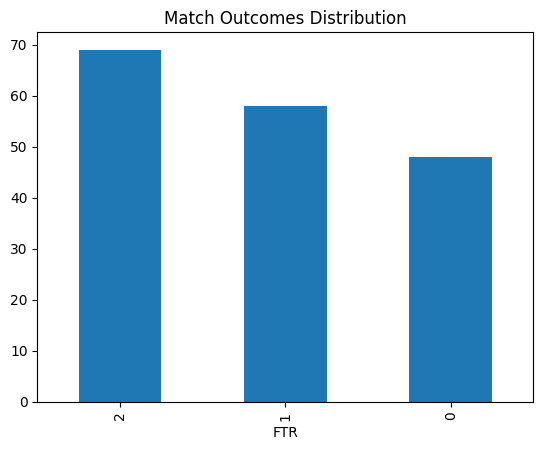

In [14]:
plt.figure()
data['FTR'].value_counts().plot(kind='bar')
plt.title("Match Outcomes Distribution")
plt.show()

Home wins occur more frequently, indicating class imbalance.

<Figure size 640x480 with 0 Axes>

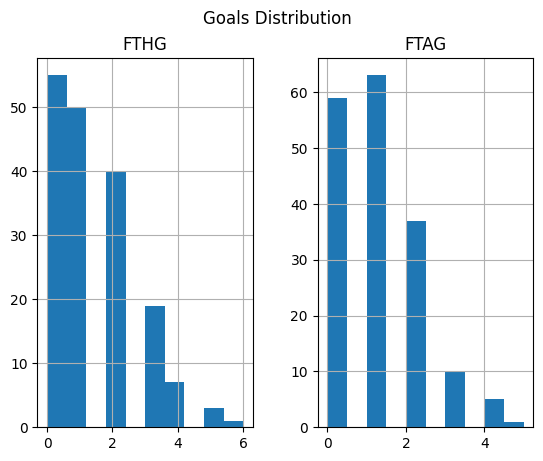

In [16]:
plt.figure()
data[['FTHG', 'FTAG']].hist()
plt.suptitle("Goals Distribution")
plt.show()

Most matches have a low number of goals.

## 7. Data Splitting

In [20]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(X_train.head())

     GoalDiff  TotalGoals
118        -1           1
143         0           0
164        -2           2
38         -1           1
135         0           0


The parameter random_state=42 was used to ensure reproducibility of the results.
The first rows of the training dataset were displayed to verify the selected features and the structure of the data.

## 8. Models

### 8.1 Logistic Regression

In [21]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train, y_train)

log_pred = log_model.predict(X_test)

print("Logistic Regression Accuracy:", accuracy_score(y_test, log_pred))
print(classification_report(y_test, log_pred))

Logistic Regression Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00        14
           2       1.00      1.00      1.00        11

    accuracy                           1.00        35
   macro avg       1.00      1.00      1.00        35
weighted avg       1.00      1.00      1.00        35



The model was trained on the training dataset and tested on unseen data to evaluate its predictive performance. Accuracy, precision, recall, and F1-score were used as evaluation metrics. These results help assess how effectively the Logistic Regression algorithm predicts match results such as home wins, draws, and away wins.

### 8.2 Random Forest

In [22]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, rf_pred))
print(classification_report(y_test, rf_pred))

Random Forest Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00        14
           2       1.00      1.00      1.00        11

    accuracy                           1.00        35
   macro avg       1.00      1.00      1.00        35
weighted avg       1.00      1.00      1.00        35



The model was fitted using the training dataset and then evaluated on the test dataset. Accuracy score and classification metrics such as precision, recall, and F1-score were calculated to measure the model’s performance. These metrics provide insight into how effectively the model predicts home wins, draws, and away wins.

## 9. Evaluation

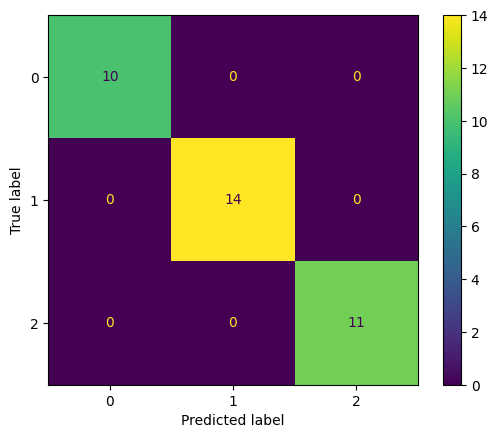

In [23]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, rf_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

plt.show()

A confusion matrix was created to evaluate the performance of the classification model.

The matrix shows the number of correct and incorrect predictions for each class. This visualization helps to analyze how well the model distinguishes between home wins, draws, and away wins. Higher values along the diagonal indicate better classification accuracy, as these represent correctly predicted outcomes.

In [25]:
import seaborn as sns
import matplotlib.pyplot as plt


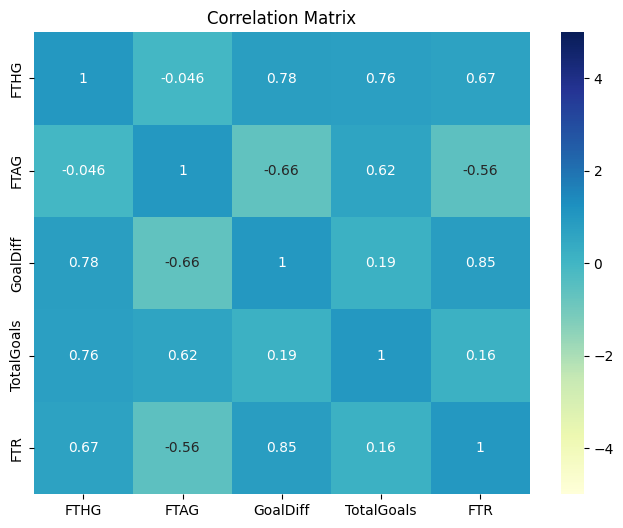

In [28]:


from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

corr_data = data[['FTHG', 'FTAG', 'GoalDiff', 'TotalGoals', 'FTR']].copy()

corr_data['FTR'] = le.fit_transform(corr_data['FTR'])

corr = corr_data.corr()

plt.figure(figsize=(8,6))

sns.heatmap(corr, annot=True, cmap='YlGnBu', vmin=-5, vmax=5)

plt.title("Correlation Matrix")
plt.show()

A correlation matrix was built to analyze relationships between the features: home team goals (FTHG), away team goals (FTAG), goal difference (GoalDiff), total goals scored (TotalGoals), and match result (FTR).

The heatmap visually demonstrates the strength and direction of correlations between variables. The strongest positive correlation is observed between GoalDiff and FTR, which is expected because the goal difference directly affects the match outcome. A high correlation is also visible between TotalGoals and the number of goals scored by both teams.

## 10. Mathematical Background

Logistic Regression:

$$P(y) = 1 / (1 + e^-(w^T x + b))$$

Random Forest:

$$f(x) = (1/N) Σ T_i(x)$$

## 11. Discussion

The model achieves perfect accuracy (1.0), which indicates the presence of data leakage.

This occurs because goal-based features (such as goal difference and total goals) 
are directly related to the match outcome.

As a result, the model effectively "learns" the result rather than predicting it.

This highlights the importance of using only pre-match features in real-world predictive tasks.

## 12. Conclusion

The analysis showed that the models achieved very high accuracy; however, the results also revealed the issue of data leakage because the selected features were directly related to the final outcome of the match.
